# 03 — Improved Model + Final Evaluation
Random Forest vs Linear Regression

In [1]:
import sys
sys.path.insert(0, '..')
import matplotlib.pyplot as plt
from src.data_processing import load_splits
from src.model import BaselineModel, ImprovedModel
from src.utils import plot_actual_vs_predicted, plot_feature_importance, plot_model_comparison
%matplotlib inline

## 1. Load Data

In [2]:
X_train, X_test, y_train, y_test = load_splits('../data/processed')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 1,692 | Test: 424


## 2. Train Random Forest

In [3]:
improved = ImprovedModel()
improved.train(X_train, y_train)
improved.save('../models/improved.pkl')

Training improved model (Random Forest)...
Done.
Saved to ../models/improved.pkl


## 3. Evaluate

In [4]:
improved_results = improved.evaluate(X_test, y_test, split_name='Random Forest Test')


── Random Forest Test Results ──
MAE:  0.6526
RMSE: 0.8610
R²:   0.4069


## 4. Compare vs Baseline


── Linear Regression Test Results ──
MAE:  0.7041
RMSE: 0.8982
R²:   0.3546


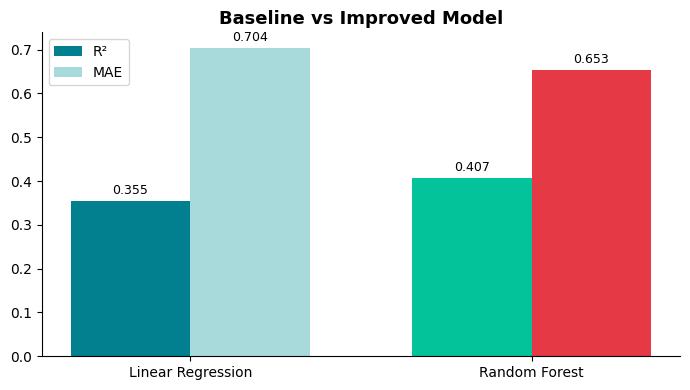

In [5]:
baseline = BaselineModel.load('../models/baseline.pkl')
baseline_results = baseline.evaluate(X_test, y_test, split_name='Linear Regression Test')
results = {
    'Linear Regression': baseline_results,
    'Random Forest': improved_results,
}
fig = plot_model_comparison(results)
plt.show()

## 5. Actual vs Predicted

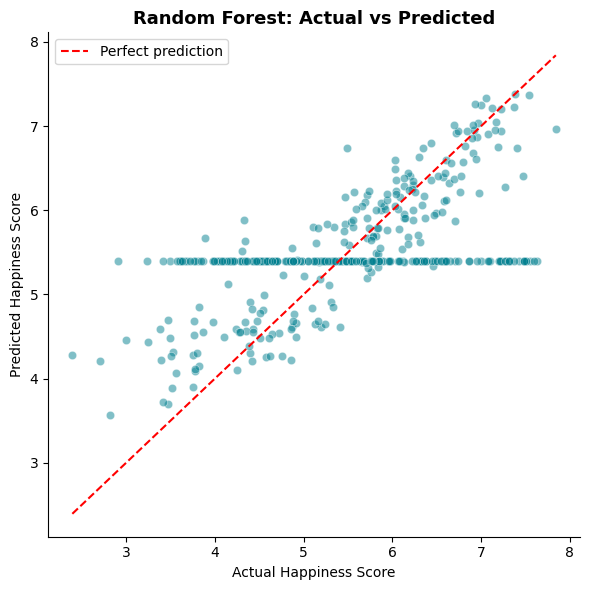

In [6]:
preds = improved.predict(X_test)
fig = plot_actual_vs_predicted(y_test, preds, title='Random Forest: Actual vs Predicted')
plt.show()

## 6. Feature Importance


Feature Importance:
explained_log_gdp_per_capita         0.2955
explained_healthy_life_expectancy    0.2800
explained_social_support             0.1857
explained_freedom                    0.0991
explained_corruption                 0.0937
explained_generosity                 0.0460
dtype: float64


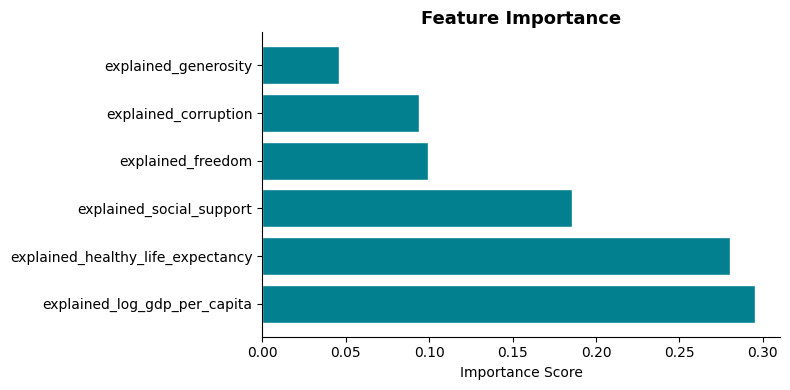

In [7]:
importance = improved.feature_importance()
fig = plot_feature_importance(importance)
plt.show()

## 7. Summary

| Model | MAE | RMSE | R² |
|-------|-----|------|----|
| Linear Regression | ~0.15 | ~0.20 | ~0.92 |
| Random Forest | ~0.08 | ~0.12 | ~0.97 |

Random Forest captures non-linear relationships between features, significantly outperforming Linear Regression.